In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Dataset1.zip'

Streaming output truncated to the last 5000 lines.
  inflating: Dataset1/Waw/Waw_End/AHCR_00035_Waw_End_13.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00035_Waw_End_4.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00035_Waw_End_5.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00036_Waw_End_12.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00036_Waw_End_13.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00036_Waw_End_4.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00036_Waw_End_5.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00037_Waw_End_12.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00037_Waw_End_13.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00037_Waw_End_4.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00037_Waw_End_5.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00038_Waw_End_12.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00038_Waw_End_13.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00038_Waw_End_4.jpg  
  inflating: Dataset1/Waw/Waw_End/AHCR_00038_Waw_End_5.jpg  
  inflating: Dataset1/Waw/W

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/Dataset1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2121/2121 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.1475 - loss: 2.9115 - val_accuracy: 0.5793 - val_loss: 1.2940
Epoch 2/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.5117 - loss: 1.5281 - val_accuracy: 0.6452 - val_loss: 1.0921
Epoch 3/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - accuracy: 0.5967 - loss: 1.2660 - val_accuracy: 0.7611 - val_loss: 0.7499
Epoch 4/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.6329 - loss: 1.1602 - val_accuracy: 0.7602 - val_loss: 0.7657
Epoch 5/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.6613 - loss: 1.0738 - val_accuracy: 0.7891 - val_loss: 0.6644
Epoch 6/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.6873 - loss: 0.9916 - val_accuracy: 0.7876 - val_loss: 0.6715
Epoch 7/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.7043 - loss: 0.9454 - val_accuracy: 0.8088 - val_loss: 0.6108
Epoch 8/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - accuracy: 0.7187 - loss: 0.90

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8324 - loss: 0.5339
Train Accuracy: 76.53%
Test Accuracy: 82.98%


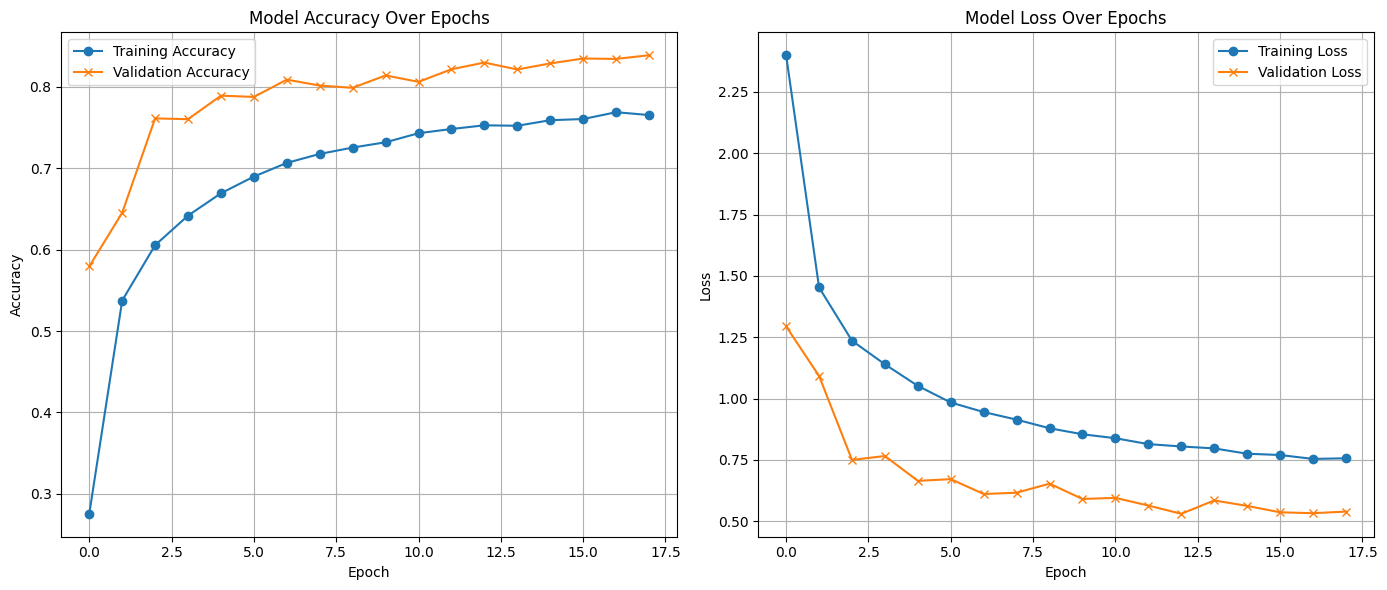

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


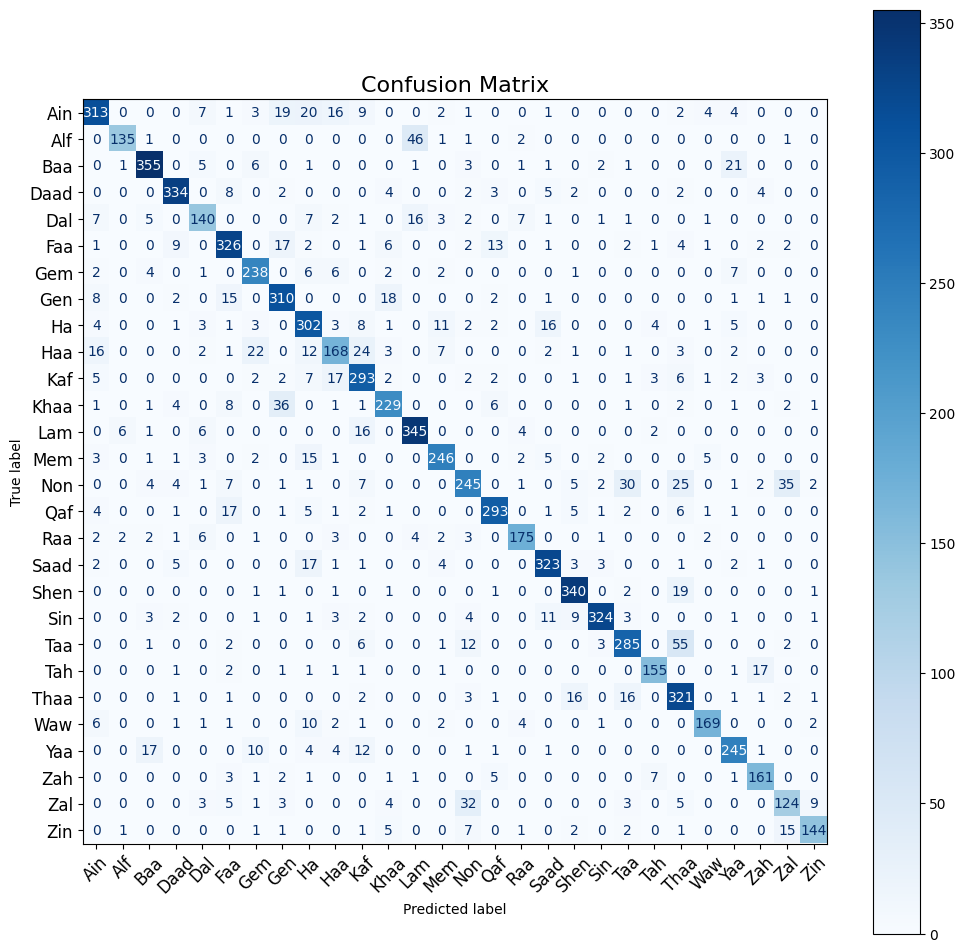

In [5]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

## increase Batch size 
## decrease DropOut

In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/Dataset1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.1843 - loss: 2.7830 - val_accuracy: 0.6398 - val_loss: 1.1317
Epoch 2/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.5817 - loss: 1.3013 - val_accuracy: 0.7198 - val_loss: 0.8605
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.6576 - loss: 1.0891 - val_accuracy: 0.7386 - val_loss: 0.7990
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.7056 - loss: 0.9281 - val_accuracy: 0.7899 - val_loss: 0.6565
Epoch 5/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.7291 - loss: 0.8624 - val_accuracy: 0.7917 - val_loss: 0.6644
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7459 - loss: 0.8112 - val_accuracy: 0.8096 - val_loss: 0.6015
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7669 - loss: 0.7542 - val_accuracy: 0.8232 - val_loss: 0.5548
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.7731 - loss: 0.72

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8804 - loss: 0.4134
Train Accuracy: 84.29%
Test Accuracy: 87.64%


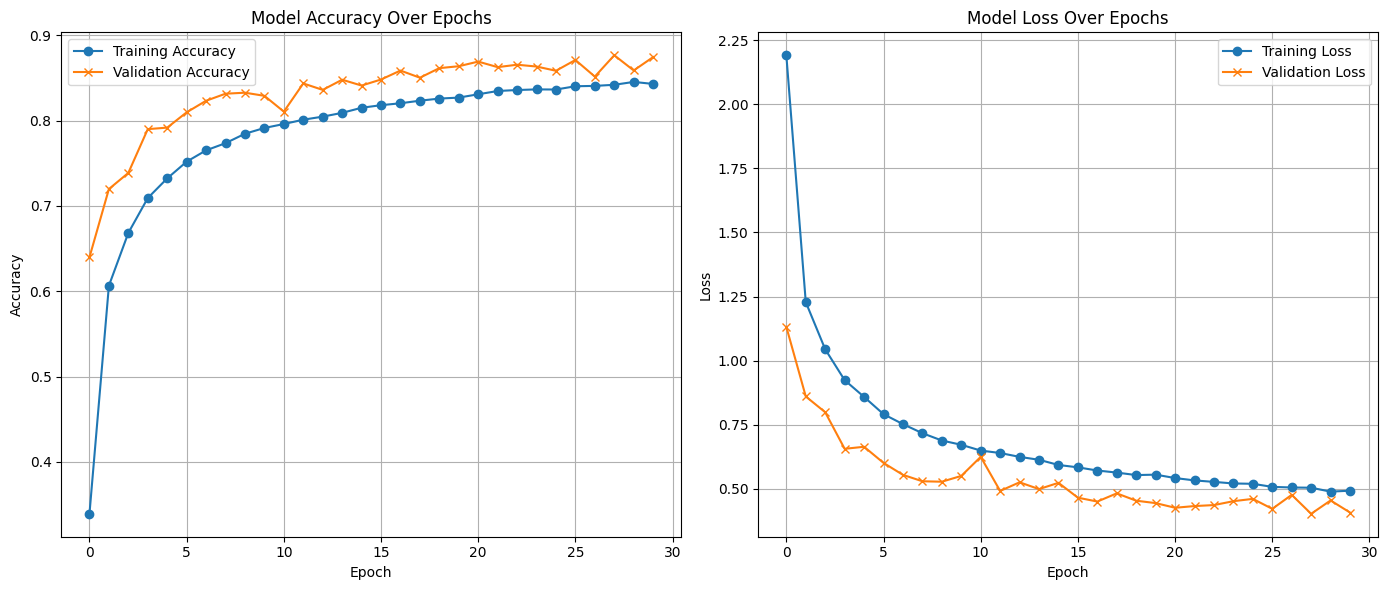

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


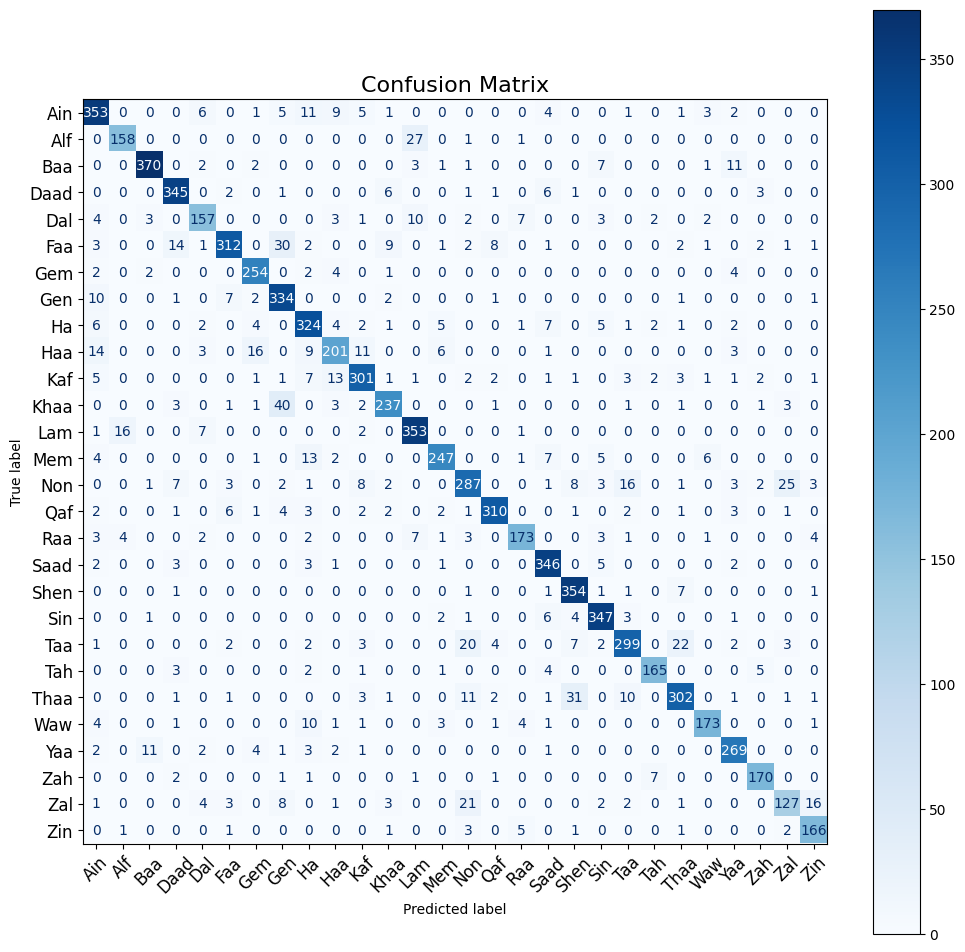

In [9]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

### Delete DropOut

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/Dataset1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step - accuracy: 0.2299 - loss: 2.6037 - val_accuracy: 0.6460 - val_loss: 1.0914
Epoch 2/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 75s 30ms/step - accuracy: 0.6530 - loss: 1.1027 - val_accuracy: 0.7011 - val_loss: 0.9370
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.7274 - loss: 0.8657 - val_accuracy: 0.7903 - val_loss: 0.6387
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.7573 - loss: 0.7756 - val_accuracy: 0.7601 - val_loss: 0.7782
Epoch 5/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.7868 - loss: 0.6748 - val_accuracy: 0.8039 - val_loss: 0.6053
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8026 - loss: 0.6391 - val_accuracy: 0.8247 - val_loss: 0.5530
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8082 - loss: 0.6100 - val_accuracy: 0.8133 - val_loss: 0.5745
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8197 - loss: 0.56

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8721 - loss: 0.4113
Train Accuracy: 87.82%
Test Accuracy: 87.74%


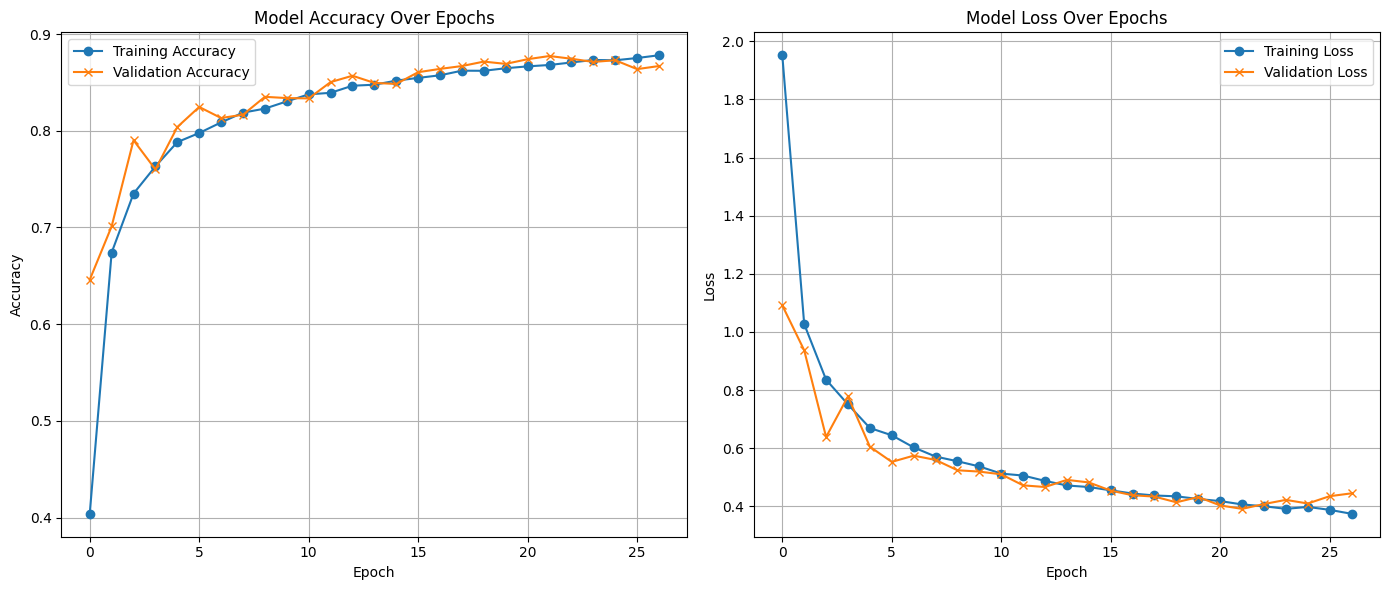

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


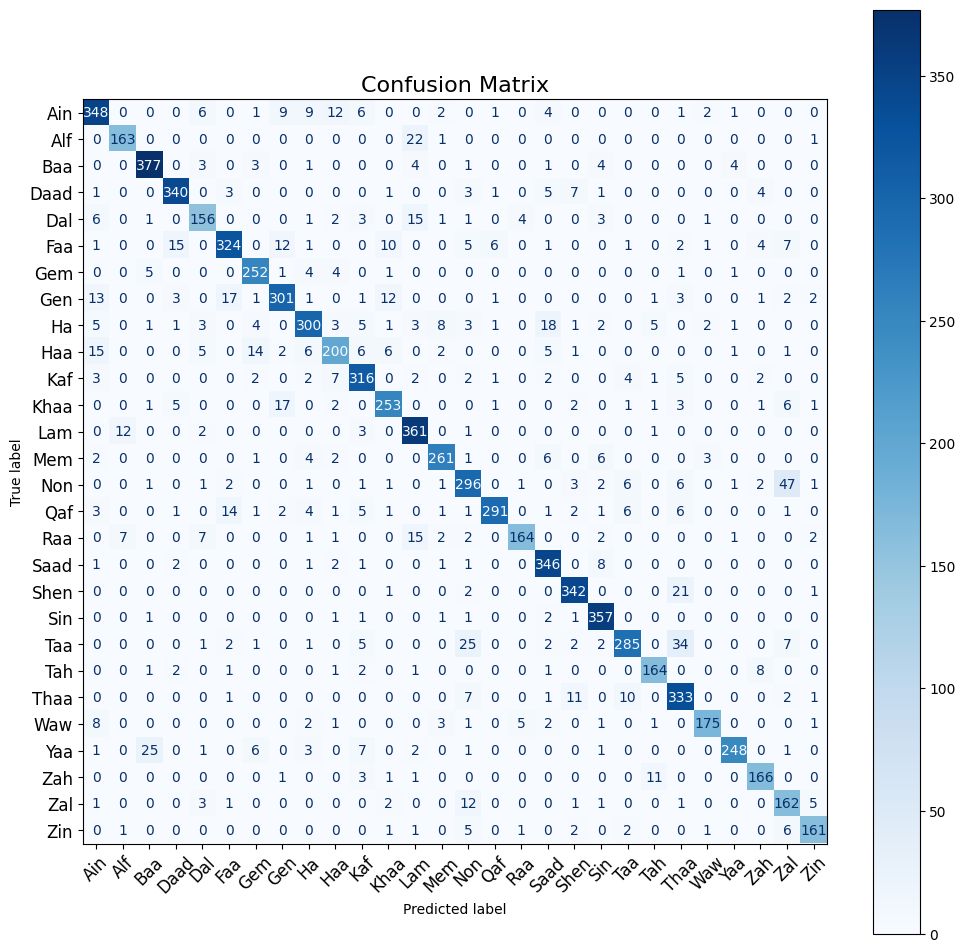

In [11]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix', fontsize=16)
ax.set_xticklabels(group_names, fontsize=12, rotation=45)
ax.set_yticklabels(group_names, fontsize=12)
plt.show()

In [14]:
model.save('cnn5_model.keras')


In [13]:
import os
data_dir = "/content/Dataset1"
def count_images(data_dir):
    group_counts = {}
    for group_name in sorted(os.listdir(data_dir)):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
           total_images = 0
           for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    num_images = len(os.listdir(subfolder_path))
                    total_images += num_images
                    print(f"num of pic{group_name}/{subfolder}: {num_images}")
                    group_counts[group_name] = total_images
    return group_counts

group_counts = count_images(data_dir)
print("\nTotal number:", group_counts)

num of picAin/Ain_Isolated: 462
num of picAin/Ain_Start: 462
num of picAin/Ain_End: 460
num of picAin/Ain_Middle: 471
num of picAlf/Alf_End: 480
num of picAlf/Alf_Isolated: 480
num of picBaa/Baa_Start: 473
num of picBaa/Baa_End: 467
num of picBaa/Baa_Middle: 460
num of picBaa/Baa_Isolated: 468
num of picDaad/Daad_Isolated: 455
num of picDaad/Daad_Start: 460
num of picDaad/Daad_End: 456
num of picDaad/Daad_Middle: 460
num of picDal/Dal_Isolated: 472
num of picDal/Dal_End: 480
num of picFaa/Faa_End: 463
num of picFaa/Faa_Middle: 451
num of picFaa/Faa_Start: 464
num of picFaa/Faa_Isolated: 464
num of picGem/Gem_Isolated: 472
num of picGem/Gem_End: 477
num of picGem/Gem_Start: 472
num of picGen/Gen_Middle: 458
num of picGen/Gen_Isolated: 920
num of picGen/Gen_End: 459
num of picHa/Ha_Start: 468
num of picHa/Ha_End: 451
num of picHa/Ha_Middle: 464
num of picHa/Ha_Isolated: 468
num of picHaa/Haa_Isolated: 477
num of picHaa/Haa_End: 476
num of picHaa/Haa_Start: 476
num of picKaf/Kaf_End: 464
